<a href="https://colab.research.google.com/github/jaewon00o0/kbu-2.1/blob/main/%EB%8D%B0%EC%9D%B4%ED%84%B0%20%EA%B4%80%EB%A6%AC%EB%A1%A0%203%EC%9B%94%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
import warnings

In [56]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 65.5 MB/s eta 0:00:00


In [2]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 5 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 2s (4,880 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and direc

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [59]:
import koreanize_matplotlib

In [53]:
plt.rc('font', family='NanumBarunGothic')

In [54]:
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
1.1 분석 배경 및 목적: 본 분석은 마케팅 모델을 헌혈자 데이터에 적용하여 향후 헌혈 여부를 예측하는 분류 문제를 해결하기 위함입니다
1.2 데이터 셋 설명: 대만 신주시의 혈액 투석 서비스 센터 데이터베이스에서 무작위로 추출한 748명의 헌혈자 데이터입니다
1.3 주요 분석 질문: 헌혈자의 최근성,빈도,총 헌혈량,최초 헌혈 경과월이 2007년 3월 헌혈 여부에 어떠한 영향을 미치는가?

In [3]:
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rc('font', family='NanumGothic')

In [4]:
file_path = 'php0iVrYT.arff'
data, meta = arff.loadarff(file_path)
df = pd.DataFrame(data)

In [5]:
df.columns = ['Recency', 'Frequency', 'Monetary', 'Time', 'Target']

In [6]:
df['Target'] = df['Target'].astype(str).str.replace("b'", "").str.replace("'", "").astype(int)
df['Target'] = df['Target'].map({1: 0, 2: 1})

In [ ]:
2.1 데이터 명세 확인: 총 748개의 레코드와 5개의 속성으로 구성되어 있습니다
2.2 결측치 분석: 본 데이터셋에는 결측치가 존재하지 않으므로, 별도의 대체나 제거 작업은 생략합니다.
2.3 기초 통계량 및 데이터 정제: 데이터 전처리 과정을 통해 모델링에 적합한 형태로 변형했습니다.

In [7]:
print("데이터셋 형태:", df.shape)
print("\n결측치 확인:\n", df.isnull().sum())
print("\n기초 통계량 요약:")
display(df.describe())

데이터셋 형태: (748, 5)

결측치 확인:
 Recency      0
Frequency    0
Monetary     0
Time         0
Target       0
dtype: int64

기초 통계량 요약:


,Recency,Frequency,Monetary,Time,Target
count,748.000000,748.000000,748.000000,748.000000,748.000000
mean,9.506684,5.514706,1378.676471,34.282086,0.237968
std,8.095396,5.839307,1459.826781,24.376714,0.426124
min,0.000000,1.000000,250.000000,2.000000,0.000000
25%,2.750000,2.000000,500.000000,16.000000,0.000000
50%,7.000000,4.000000,1000.000000,28.000000,0.000000
75%,14.000000,7.000000,1750.000000,50.000000,0.000000
max,74.000000,50.000000,12500.000000,98.000000,1.000000


In [ ]:
3.1 수치형 변수 분석 변수들의 분포, 왜도, 첨도를 확인하여 데이터의 정규성을 검토합니다.
3.2 범주형 변수 분석:타겟 변수의 비율을 확인하여 클래스 불균형 여부를 파악합니다.데이터 명세서에 따르면 비헌혈자가 76%, 헌혈자가 24%를 차지합니다
3.3 파생 변수 생성 :연속형 수치 데이터를 비즈니스 관점에서 의미 있는 구간으로 나누어 범주형 변수로 변환합니다
.이를 통해 특정 타겟층의 행동 패턴을 직관적으로 파악할 수 있습니다.

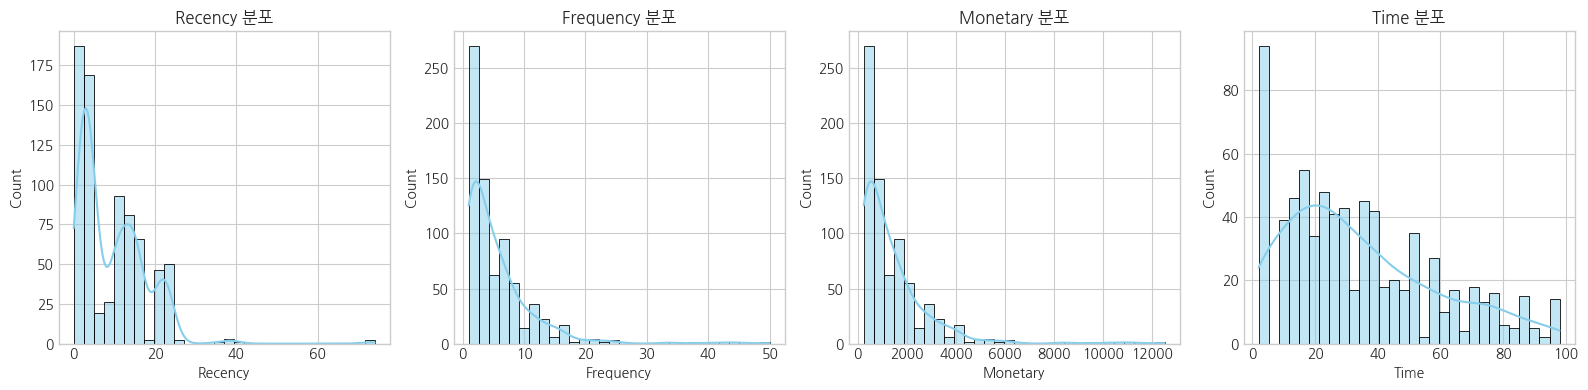

In [60]:
# 수치형 변수 분포
features = ['Recency', 'Frequency', 'Monetary', 'Time']
plt.figure(figsize=(16, 4))
for i, col in enumerate(features, 1):
    plt.subplot(1, 4, i)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'{col} 분포')
plt.tight_layout()
plt.show()

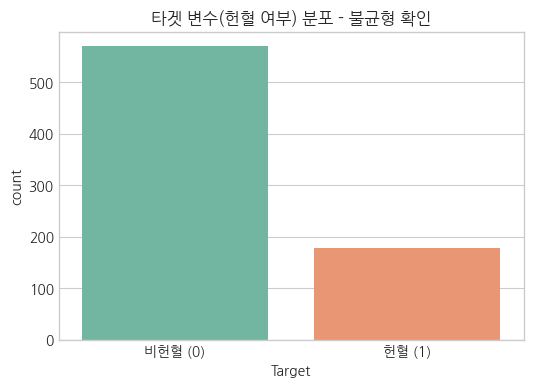

In [61]:
# 타겟 변수 빈도수 분석
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Target', palette='Set2')
plt.title('타겟 변수(헌혈 여부) 분포 불균형 확인')
plt.xticks([0, 1], ['비헌혈 (0)', '헌혈 (1)'])
plt.show()

In [24]:
ins_recency = [-1, 3, 12, df['Recency'].max()]
labels_recency = ['최근(0~3개월)', '보통(4~12개월)', '비활성(13개월 이상)']
df['Recency_Group'] = pd.cut(df['Recency'], bins=ins_recency, labels=labels_recency)

In [25]:
bins_frequency = [0, 1, 5, df['Frequency'].max()]
labels_frequency = ['1회(신규)', '2~5회(가끔)', '6회 이상(단골)']
df['Frequency_Group'] = pd.cut(df['Frequency'], bins=bins_frequency, labels=labels_frequency)

In [129]:
print("파생 변수 생성 결과 확인")
print(df[['Recency', 'Recency_Group', 'Frequency', 'Frequency_Group']].head(10))

파생 변수 생성 결과 확인
   Recency Recency_Group  Frequency Frequency_Group
0      2.0     최근(0~3개월)       50.0       6회 이상(우수)
1      0.0     최근(0~3개월)       13.0       6회 이상(우수)
2      1.0     최근(0~3개월)       16.0       6회 이상(우수)
3      2.0     최근(0~3개월)       20.0       6회 이상(우수)
4      1.0     최근(0~3개월)       24.0       6회 이상(우수)
5      4.0    보통(4~12개월)        4.0        2~5회(가끔)
6      2.0     최근(0~3개월)        7.0       6회 이상(우수)
7      1.0     최근(0~3개월)       12.0       6회 이상(우수)
8      2.0     최근(0~3개월)        9.0       6회 이상(우수)
9      5.0    보통(4~12개월)       46.0       6회 이상(우수)


In [130]:
print("\n최근 헌혈 경과월 그룹별 분포")
print(df['Recency_Group'].value_counts())


최근 헌혈 경과월 그룹별 분포
Recency_Group
보통(4~12개월)      294
비활성(13개월 이상)    254
최근(0~3개월)       200
Name: count, dtype: int64


In [ ]:
4.1 수치형 변수 간 상관관계: 피어슨 상관 계수 히트맵을 통해 독립 변수 간의 다중공선성을 확인합니다.
4.2 타겟 변수 기반 심층 분석: 헌혈 여부에 따른 각 수치형 변수의 분포 차이를 비교하여, 종속 변수에 미치는 영향을 시각화합니다.
4.3 세그먼트별 비교 분석: 단일 변수가 아닌 두 개 이상의 변수를 결합하여 고객 세그먼트를 정의하고,각 세그먼트별로 타겟 월의 헌혈 참여율이
어떻게 달라지는지 심층 분석합니다.

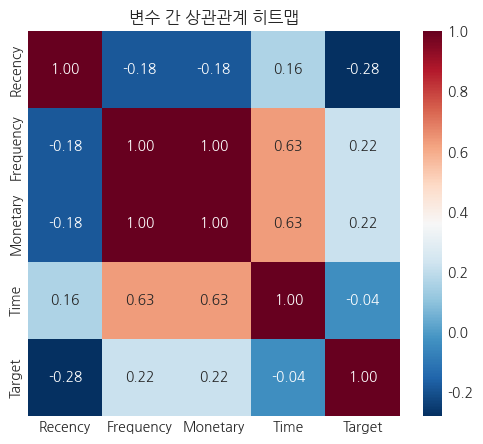

In [64]:
plt.figure(figsize=(6, 5))
numerical_cols = ['Recency', 'Frequency', 'Monetary', 'Time', 'Target']
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='RdBu_r', fmt=".2f")
plt.title('변수 간 상관관계 히트맵')
plt.show()

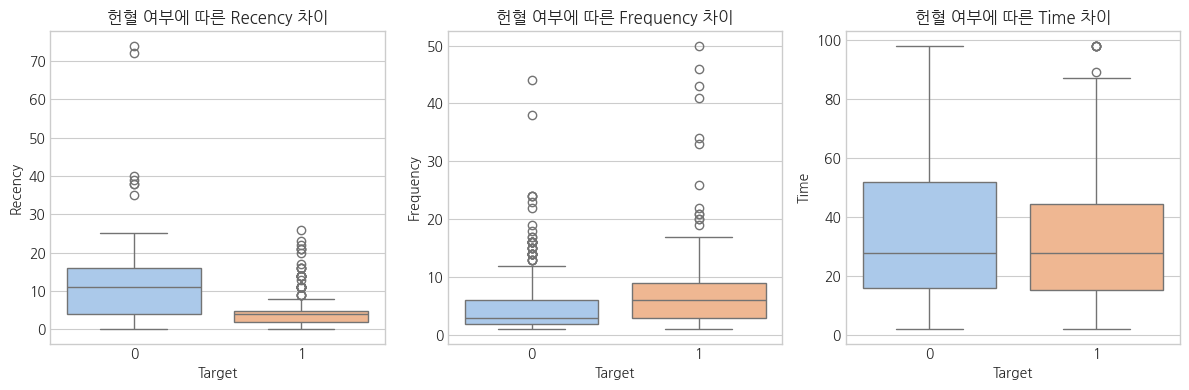

In [65]:
plt.figure(figsize=(12, 4))
for i, col in enumerate(['Recency', 'Frequency', 'Time'], 1):
    plt.subplot(1, 3, i)
    sns.boxplot(x='Target', y=col, data=df, palette='pastel')
    plt.title(f'헌혈 여부에 따른 {col} 차이')
plt.tight_layout()
plt.show()

In [66]:
bins_recency = [-1, 3, 12, df['Recency'].max()]
labels_recency = ['최근(0~3개월)', '보통(4~12개월)', '비활성(13개월 이상)']
df['Recency_Group'] = pd.cut(df['Recency'], bins=bins_recency, labels=labels_recency)

In [32]:
bins_frequency = [0, 1, 5, df['Frequency'].max()]
labels_frequency = ['1회(신규)', '2~5회(가끔)', '6회 이상(우수)']
df['Frequency_Group'] = pd.cut(df['Frequency'], bins=bins_frequency, labels=labels_frequency)

In [131]:
segment_pivot = df.pivot_table(index='Recency_Group',
                               columns='Frequency_Group',
                               values='Target',
                               aggfunc='mean')

print("세그먼트별 헌혈 확률 피벗 테이블")
display(segment_pivot * 100)

세그먼트별 헌혈 확률 피벗 테이블


Frequency_Group,1회(신규),2~5회(가끔),6회 이상(우수)
Recency_Group,,,
최근(0~3개월),20.588235,29.113924,51.724138
보통(4~12개월),19.230769,23.966942,34.710744
비활성(13개월 이상),4.166667,11.382114,8.474576


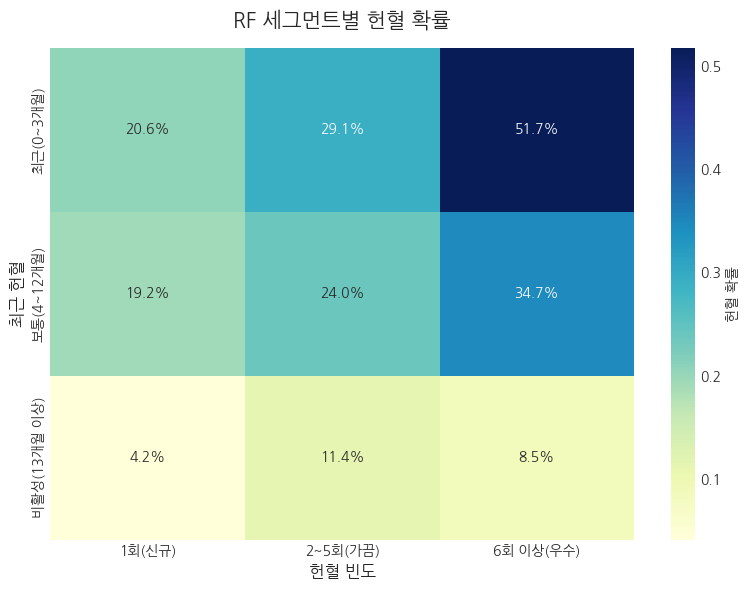

In [132]:
plt.figure(figsize=(8, 6))
sns.heatmap(segment_pivot, annot=True, fmt=".1%", cmap="YlGnBu", cbar_kws={'label': '헌혈 확률'})
plt.title('RF 세그먼트별 헌혈 확률', fontsize=15, pad=15)
plt.xlabel('헌혈 빈도', fontsize=12)
plt.ylabel('최근 헌혈', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
5.1 주요 패턴 발견 및 가설 검증: 시각화 결과, 최근에 헌혈한 사람일수록, 총 헌혈 횟수가 많은 사람일수록 다음 달에 다시 헌혈할 확률이 높게 나타나는 패턴을 보입니다.
5.2 머신러닝 변수 중요도 파악: 이를 명확히 하기 위해 랜덤 포레스트 분류기를 사용하여 독립 변수들이 예측에 미치는 영향력을 시각화합니다.
 5.3 예상치 못한 발견: 3차원 공간에서 주요 변수간의 입체적인 관계를 시각화하여, 2차원 분석에서는 포착하기 어려웠던 특이 패턴이나 데이터의 구조적 한계점을 도출합니다.

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D



In [14]:
X = df[['Recency', 'Frequency', 'Time']]
y = df['Target']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=248, random_state=42, stratify=y)

In [19]:
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [20]:
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

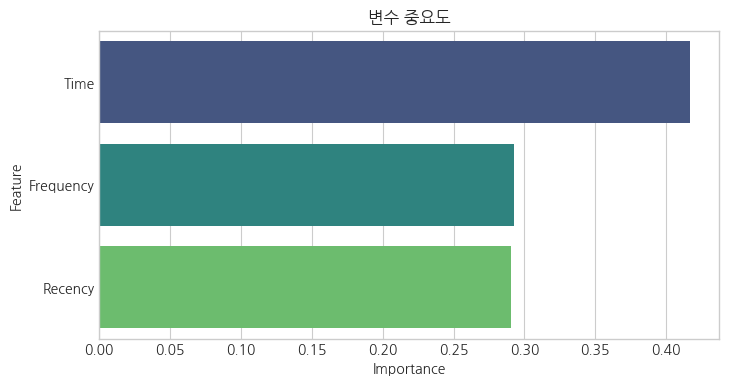

In [133]:
plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('변수 중요도')
plt.show()

In [117]:
from IPython.display import display

In [120]:
if df['Target'].dtype == 'O' or str(df['Target'].dtype).startswith('bytes'):
    df['Target'] = df['Target'].astype(str).str.replace("b'", "").str.replace("'", "").astype(int)
if 2 in df['Target'].values:
    df['Target'] = df['Target'].map({1: 0, 2: 1})

In [123]:
df_0 = df[df['Target'] == 0]
df_1 = df[df['Target'] == 1]

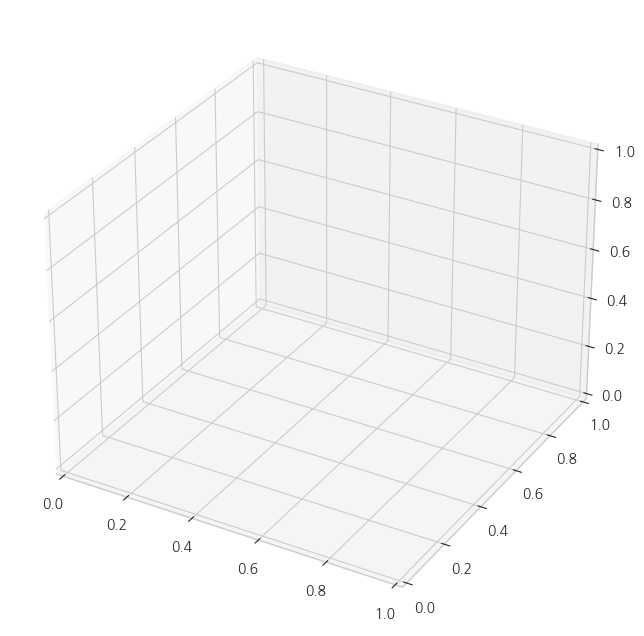

In [124]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

In [125]:
ax.scatter(df_0['Recency'], df_0['Time'], df_0['Frequency'],
           color='royalblue', alpha=0.4, s=30, edgecolor='w', linewidth=0.5, label='비헌혈(0)')
ax.scatter(df_1['Recency'], df_1['Time'], df_1['Frequency'],
           color='crimson', alpha=0.8, s=35, edgecolor='w', linewidth=0.5, label='헌혈(1)')

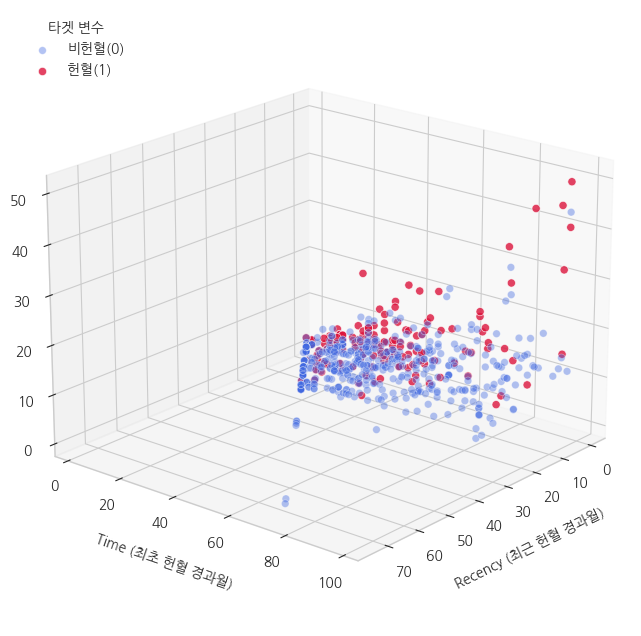

In [128]:
plt.close()
display(fig)

In [ ]:
6.1 분석 요약: 헌혈 예측에 가장 큰 영향을 미치는 변수는 과거 헌혈 후 경과 시간과 첫 헌혈 후 경과 시간으로 나타났습니다.
6.2 비즈니스 제언:마지막 헌혈 이후 특정 기간이 지난 집단을 '이탈 위험군'으로 정의하여, 주기적인 헌혈 독려 알림을 발송하는 타겟 마케팅을 제안합니다.
6.3 한계점 및 추후 과제:타겟 데이터의 비율이 76:24로 불균형합니다.
머신러닝 모델의 정확도를 더욱 높이기 위해 오버샘플링 기법을 도입하여 소수 클래스에 대한 예측 성능을 개선해야 합니다.